# (연구) HST example 1
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [기하학적 딥러닝, 논문연구]

### Import

In [1]:
import heavysnow as hs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybase as pb
import plotnine as p9
import rpy2 
%load_ext rpy2.ipython

### Data 

In [447]:
f=np.array([-1,-1,-1,1,-1,-1,-1,1,1,1,-1,1,1,1])*1.0
n=len(f)
V=list(range(n))
W=np.zeros([n,n])
for i in range(n):
    for j in range(n):
        if abs(i-j)==1: W[i,j]=1
W[0,0]=1
W[n-1,n-1]=1

In [448]:
gs1=hs.GraphSignal(V,W,f)

### HST

In [451]:
# hst1=hs.HeavySnowTransform(gs1)
# hst2=hs.HeavySnowTransform(gs1)
# hst3=hs.HeavySnowTransform(gs1)
# hst4=hs.HeavySnowTransform(gs1)
# hst5=hs.HeavySnowTransform(gs1)
# hst6=hs.HeavySnowTransform(gs1)
# hst7=hs.HeavySnowTransform(gs1)
hst8=hs.HeavySnowTransform(gs1)

# hst1.snow(tau=10,b=0.03)
# hst2.snow(tau=50,b=0.03)
# hst3.snow(tau=100,b=0.03)
# hst4.snow(tau=500,b=0.03)
# hst5.snow(tau=1000,b=0.03)
# hst6.snow(tau=5000,b=0.03)
# hst7.snow(tau=10000,b=0.03)
hst8.snow(tau=16000,b=0.03)

HST (tau= 16000, b=0.03)
16000/16000
HST completed and all history is recorded.


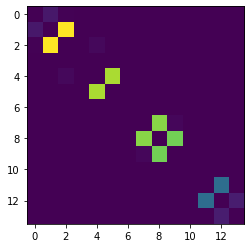

In [452]:
plt.imshow(hst8.snowweight)

### 시각화를 위해서 R로 자료를 옮김

In [453]:
pb.push(hst8.tau,"maxtau")
pb.push(hst8.graphweight,"W_Graph")
pb.push(hst8.euclidweight,"W_Euclid")
pb.push(hst8.snowweight,"W_HST")
pb.push(hst8.V,"V")
pb.push(hst8.f,"f")
pb.push(hst8.n,"n")

### R을 활용한 시각화 (1): 원래자료 

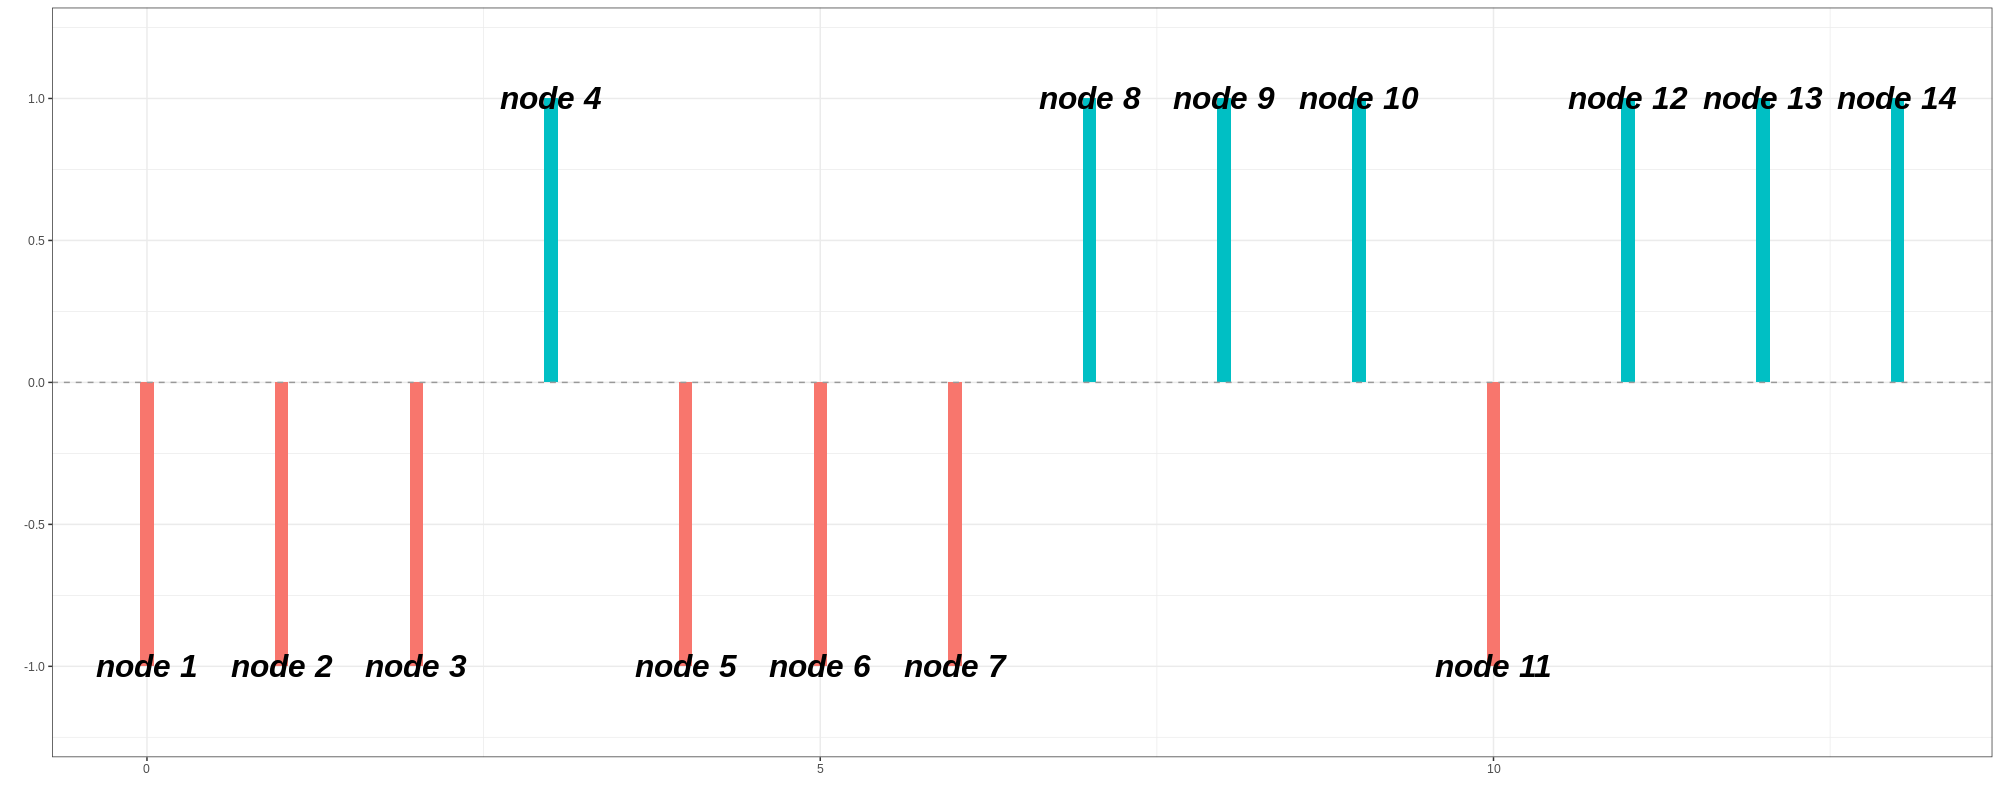

In [483]:
%%R -w 2000 -h 800 -r 100
library(tidyverse)
library(latex2exp)
library(gridExtra)
source('rbase.R')
Vtext=str_c('node ',V+1)
fig0<-ggplot(data=tibble(V=V,f=f,Vtext=Vtext),aes(x=V,y=f,label=Vtext))+
geom_col(aes(fill=(f>0)),width=0.1)+geom_hline(aes(yintercept=0),col="gray60",lty=2)+
geom_text(fontface = 4,size=8)+
xlab("")+ylab("")+guides(fill=FALSE)+theme(plot.title=element_text(face="bold.italic"))+theme_bw()+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 15, color = "black", face = "bold.italic"))+
ylim(-1.2,1.2)+
theme(plot.title=element_text(face="bold.italic"))
#ggsave(plot=p0,"./fig/2021-0217_fig0.pdf",width=20,height=6)
fig0

### R을 활용한 시각화 (2): Weight matrix 와 Eigen plot 

`-` `ggplot`에서 `geom_tile`을 사용하기 위해서 매트릭스 형태인 `W_Graph`, `W_Euclid`, `W_HST`를 길게 펼친다. 결과를 각각 `W_Graph_long`, `W_Euclid_long`, `W_HST_long`에 저장한다. 

In [455]:
%%R
grid<-expand.grid(x=1:n,y=1:n)
W_Graph_long<-as_tibble(cbind(grid,as.vector(W_Graph)));names(W_Graph_long)<-c("x","y","W")
W_Euclid_long<-as_tibble(cbind(grid,as.vector(W_Euclid)));names(W_Euclid_long)<-c("x","y","W")
W_HST_long<-as_tibble(cbind(grid,as.vector(W_HST)));names(W_HST_long)<-c("x","y","W")

`-` 그래프퓨리에 변환: $(\bf{f},\bf{W})$에 그래프 퓨리에 변환을 수행함.  

In [457]:
%%R
source('heavysnow.R')
gfftrslt_Euclid<-gfft(f,W_Euclid)
gfftrslt_Graph<-gfft(f,W_Graph)
gfftrslt_HST<-gfft(f,W_HST)

`-` 그래프 퓨리에 변환의 결과 고유치, 고유벡터, $\bf{\bar{f}}$가 반환됨. 

In [458]:
%%R
head(gfftrslt_HST)

$λ
 [1] 1.989947e+00 1.978106e+00 1.953145e+00 1.903928e+00 1.021892e+00
 [6] 9.607193e-02 4.809724e-02 8.812003e-03 2.250954e-06 1.676770e-13
[11] 6.980501e-16 3.525333e-17 3.746141e-19 2.067325e-27

$Ψ
               [,1]          [,2]          [,3]          [,4]          [,5]
 [1,]  1.135811e-05  1.561745e-20  4.064476e-05 -1.134499e-23  4.337418e-21
 [2,] -1.940973e-01 -9.965519e-19 -6.799420e-01  1.221745e-25 -2.714798e-19
 [3,]  2.017985e-01 -1.030739e-18  6.777047e-01  1.276034e-25 -2.807936e-19
 [4,]  1.456331e-28  4.056461e-13 -4.017680e-29 -2.363475e-18  1.110369e-12
 [5,] -6.799295e-01 -3.077144e-18  1.941701e-01  4.276134e-25 -8.383212e-19
 [6,]  6.777164e-01 -3.065694e-18 -2.017256e-01  4.261959e-25 -8.352043e-19
 [7,] -2.538415e-20  1.267517e-17  7.677806e-21  2.746135e-18 -1.743433e-16
 [8,] -4.135112e-24 -5.029855e-01  1.277996e-24  8.089240e-08 -6.991765e-01
 [9,]  1.905401e-24  7.110087e-01 -6.006135e-25 -1.090221e-07 -4.938317e-04
[10,] -4.938906e-25 -4.913982e-01  1

`-` 시각화코드 

TableGrob (2 x 3) "arrange": 6 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (1-1,2-2) arrange gtable[layout]
3 3 (1-1,3-3) arrange gtable[layout]
4 4 (2-2,1-1) arrange gtable[layout]
5 5 (2-2,2-2) arrange gtable[layout]
6 6 (2-2,3-3) arrange gtable[layout]


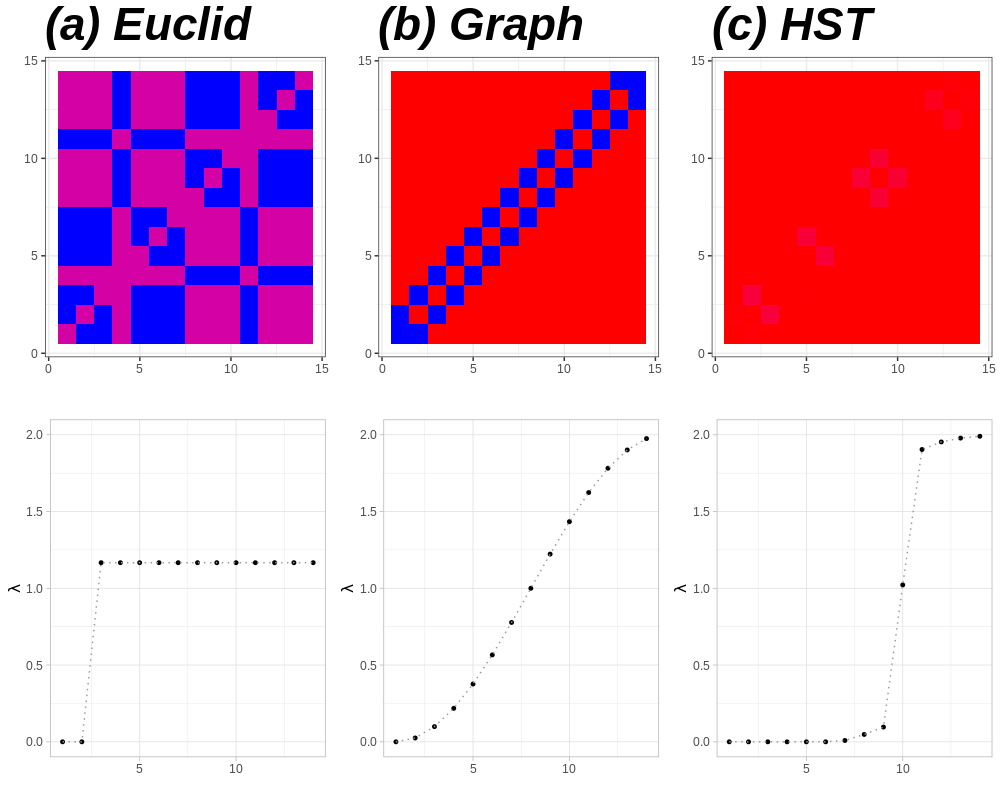

In [479]:
%%R -w 1000 -h 800 -r 100
library(gridExtra)

fig1_1<-ggplot()+geom_tile(data=W_Euclid_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
scale_fill_gradient2(low="red",high="blue",mid="purple",midpoint=0.25,breaks=c(0,0.5,0.99))+
labs(fill=TeX('$W$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(a) Euclid")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

fig1_2<-ggplot()+geom_tile(data=W_Graph_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
scale_fill_gradient2(low="red",high="blue",mid="purple",midpoint=0.5,breaks=c(0,0.5,0.99))+
labs(fill=TeX('$\\hat{W}$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(b) Graph")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

fig1_3<-ggplot()+geom_tile(data=W_HST_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
scale_fill_gradient2(low="red",high="blue",mid="purple",midpoint=0.5,breaks=c(0,0.5,0.99))+
labs(fill=TeX('$\\hat{W}(\\tau)$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(c) HST")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

fig1_4<-eigenplot(gfftrslt_Euclid)+ylim(0,2)+theme_light()
fig1_5<-eigenplot(gfftrslt_Graph)+ylim(0,2)+theme_light()
fig1_6<-eigenplot(gfftrslt_HST)+ylim(0,2)+theme_light()
fig1=grid.arrange(fig1_1,fig1_2,fig1_3,fig1_4,fig1_5,fig1_6,ncol=3,nrow=2)
fig1
#ggsave(plot=grid.arrange(p1_a,p1_b,p1_c,ncol=3),"2021-07-22_fig1.png",width=20,height=4)

### R을 활용한 시각화 (3): Decomposition 

`-` 디콤포지션을 수행하고 결과를 저장: $(\bf{f},\bf{W})$에 decomposition을 수행하고 그 결과를 각각 `decomprslt_Euclid`, `decomprslt_Graph`, `decomprslt_HST`에 저장한다. 

In [475]:
%%R 
decomprslt_Euclid<-decompose(f,W_Euclid,V=1:n) # 0, 35000, 60000, 80000
decomprslt_Graph<-decompose(f,W_Graph,V=1:n) # 0, 35000, 60000, 80000
decomprslt_HST<-decompose(f,W_HST,V=1:n) # 0, 35000, 60000, 80000

`-` 디콤포지션 결과는 아래와 같은 형태임 

In [476]:
%%R
head(decomprslt_Euclid)

# A tibble: 6 x 5
      V Vindex eigenvectorindex      fhat eigenvalue
  <int>  <int>            <dbl>     <dbl>      <dbl>
1     1      1                1  0          1.34e-16
2     2      2                1  1.80e-17   1.34e-16
3     3      3                1  1.32e-16   1.34e-16
4     4      4                1  1   e+ 0   1.34e-16
5     5      5                1 -3.60e-16   1.34e-16
6     6      6                1  6.52e-16   1.34e-16


In [462]:
%%R 
decomprslt_Euclid$method="Euclid"
decomprslt_Graph$method="Graph"
decomprslt_HST$method="HST"
decomprslt<-rbind(decomprslt_Euclid,decomprslt_Graph,decomprslt_HST)

`-` 디콤포지션결과를 시각화한다. `geom_col`과 `facet_grid`를 이용. 

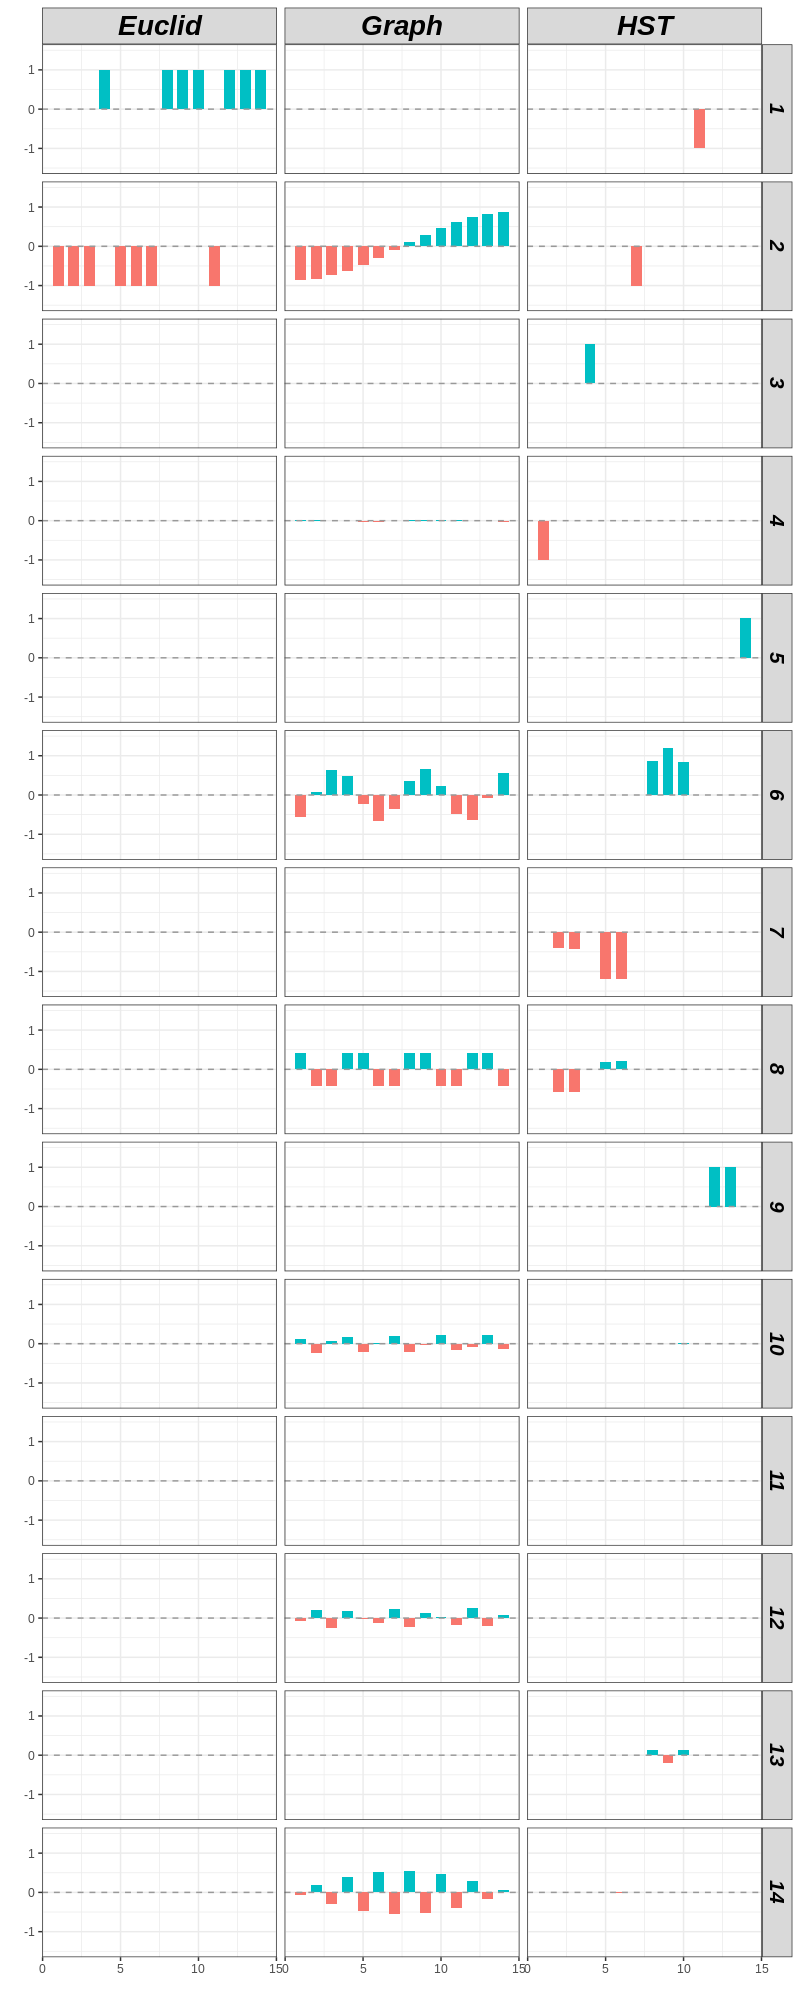

In [477]:
%%R -w 800 -h 2000 -r 100
fig2<-ggplot(data=decomprslt,aes(x=V,y=fhat))+
geom_col(aes(fill=fhat>0),width=0.7)+facet_grid(eigenvectorindex~method)+geom_hline(aes(yintercept=0),col="gray60",lty=2)+
xlab("")+ylab("")+guides(fill=FALSE)+theme(plot.title=element_text(face="bold.italic"))+theme_bw()+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 15, color = "black", face = "bold.italic"))+
ylim(-1.5,1.5)+
theme(plot.title=element_text(face="bold.italic"))
fig2
#ggsave(plot=fig2,"./fig/2021-0514_fig2.pdf",width=20,height=6)